<div style="background-color: white; color: #2F1192; padding: 15px; border-radius: 5px; font-family: 'Times New Roman', Times, serif;">
    <h2 style="color: #2F1192; margin: 0; font-size:30px; "><b>Task 2: Predict Future Stock Prices (Short-Term) </b></h2>
</div>

In [20]:
!pip install yfinance

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print('All libraries loaded!')

All libraries loaded!


In [31]:
# Download 2 years of Apple stock data
ticker = 'AAPL'   # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2024-01-01', end='2026-01-01')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(502, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562164,186.330827,181.831752,185.055258,82488700
2024-01-03,182.187775,183.799536,181.376945,182.158112,58414500
2024-01-04,179.873962,181.040748,178.855492,180.111267,71983600
2024-01-05,179.152130,180.714448,178.153440,179.953077,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500


In [32]:
# Create target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)
# Drop the last row (it has no 'next day' value)
df = df.dropna()
# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (501, 5)
Target shape: (501,)


In [33]:
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 101


In [37]:
# Random Forest 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [38]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $10.34
R2 Score: 0.4401


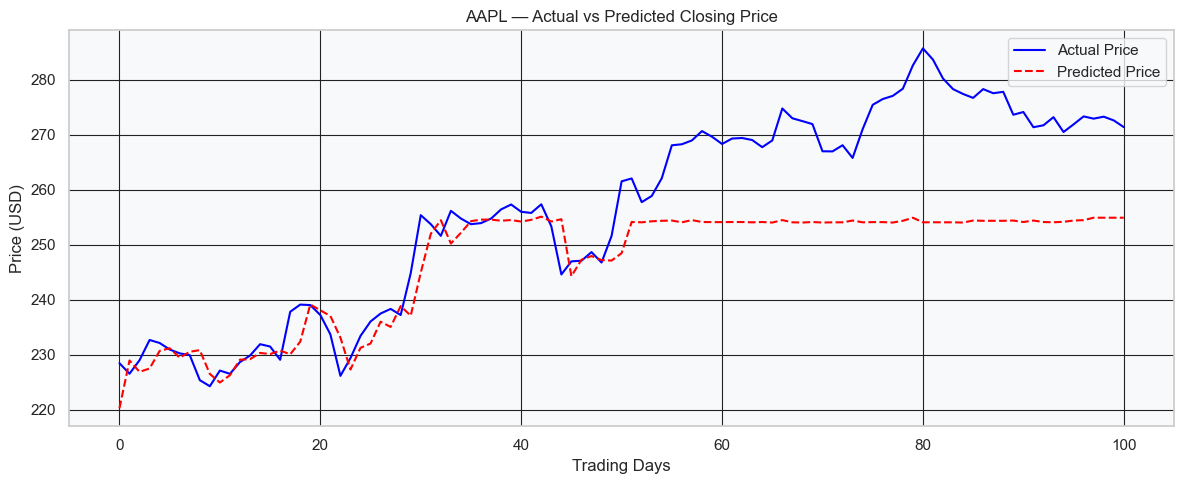

In [39]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(
    y_pred, 
    label='Predicted Price', 
    color='red',  
    linewidth=1.5, 
    linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [41]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $2.39
R2 Score: 0.9643


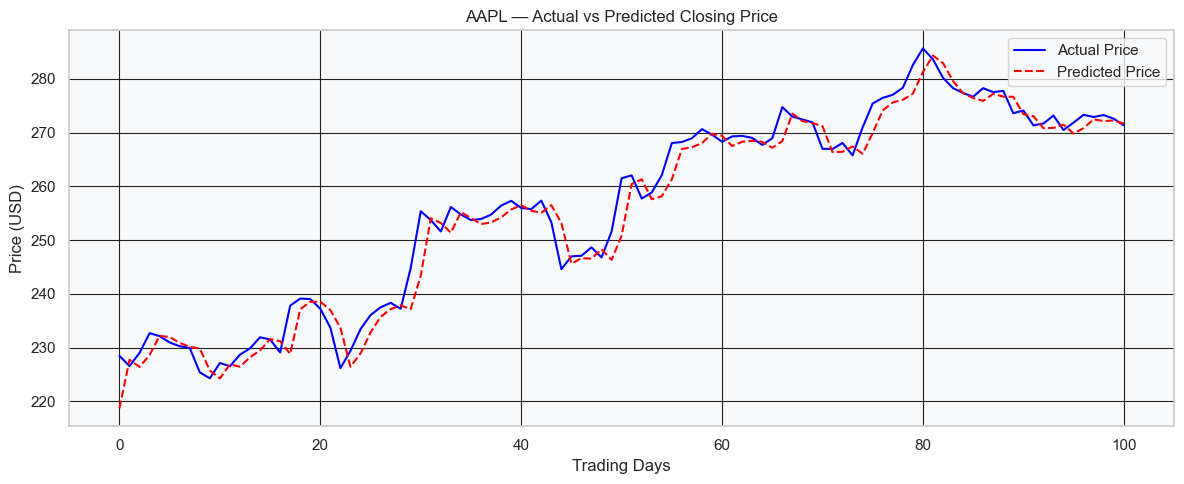

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(
    y_pred, 
    label='Predicted Price', 
    color='red',  
    linewidth=1.5, 
    linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Task 2: Summary of Findings
- Evaluated two models to predict short-term stock prices over 100 trading days.
- **Model 1 (Random Forest)** performed poorly (MAE: **$10.34**, R2: **0.4401**), with predictions completely flattening out after 50 days.

- **Model 2 (Linear Regression)** performed exceptionally well (MAE: **$2.39**, R2: **0.9643**), closely tracking the actual price fluctuations.
- **Linear Regression was the better model** because it directly captured the continuous linear relationships of lag features, avoiding the stagnation limits of the baseline model.